<a href="https://colab.research.google.com/github/JackTurner123/fruit-database/blob/main/hw/assignment_2_mist5400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: How Much Does Your Prompt Matter?

**Course:** MIST5400 Foundations of AI in Business, Spring 2026  
**Due Date:** Tue, April 7th 2026, end of day.       
**Submission:** Downaload this jupyter notebook as a `.ipynb` file, then upload in eLC.

---

### Save this notebook to your own google drive before any edits!

---

## Overview

In this assignment, you will use a GenAI tool of your choice (e.g., ChatGPT, Claude, Gemini, Copilot) to help you complete a machine learning task. You will explore **how to use GenAI tools effectively as an analysis assistant** for your course project.

A key theme of this assignment is **prompt engineering**. Well, hold on for a second, like we discussed in class, we **WON'T** discuss detailed prompt engineering techniques in this course, as it'll become obsolete fast when new models are released. At the end of the day it's just all about clearly describing what output you'd like and how you'd like to get a task done **in natural langauge**.

But relevant to the few prompt writing principles we mentioned in class, you will discover how the level of detail in your prompt changes the quality and usefulness of the output.



---
## Setup: Load the Dataset

You will use the **Titanic dataset** (predicting passenger survival — a classification task). This is a well-known dataset so you can focus on the prompting experience rather than domain knowledge.

Run the cell below to load the Titanic dataset. It is available directly via the `seaborn` library — no file download needed.

The target variable column is 'survived' (0 = not survived, 1= survived).

In [2]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
df = sns.load_dataset('titanic')
df = df.drop(columns=['alive'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


---
## Part A: Descriptive Analysis with GenAI Assistance

Before building any model, it is important to understand your data. Use your GenAI tool to help you write code that explores the Titanic dataset.

**Your task:**
1. Ask your GenAI tool to help you write Python code to explore this dataset (summary statistics, distribution of survival etc).
2. **Paste and run** the generated code below. Fix any errors if needed.
3. In the reflection cell, report **2-3 interesting patterns** you found. Be concise — one or two sentences per pattern.

Record the exact prompt you used below.

**Prompt you used:**

> I am working with the Titanic dataset in Python using pandas and seaborn. Write beginner-friendly Python code to explore the dataset, including summary statistics, missing values, and visualizations of survival distribution overall and by variables like sex and passenger class.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.7+ KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.0000

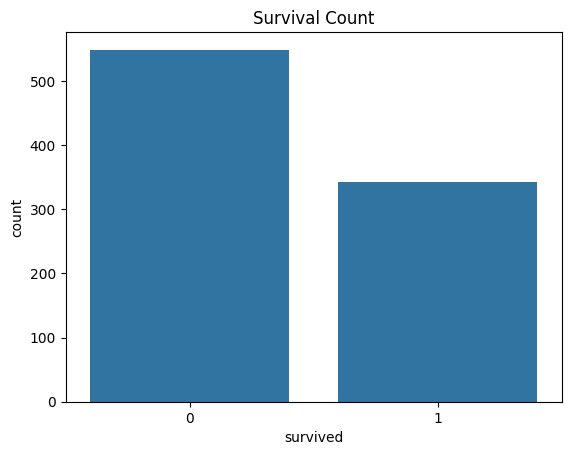

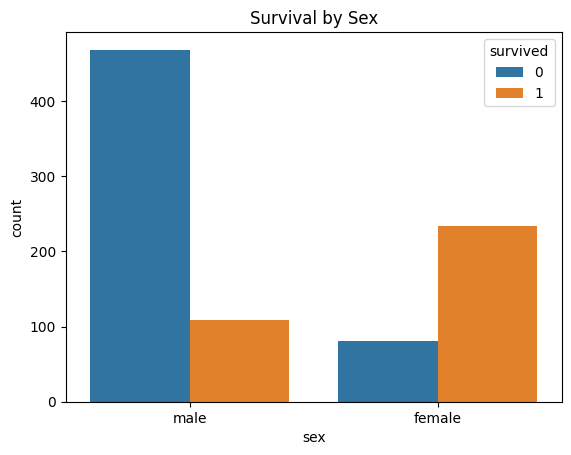

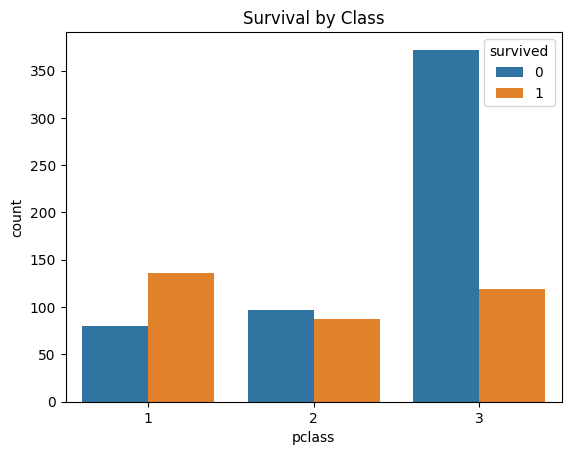

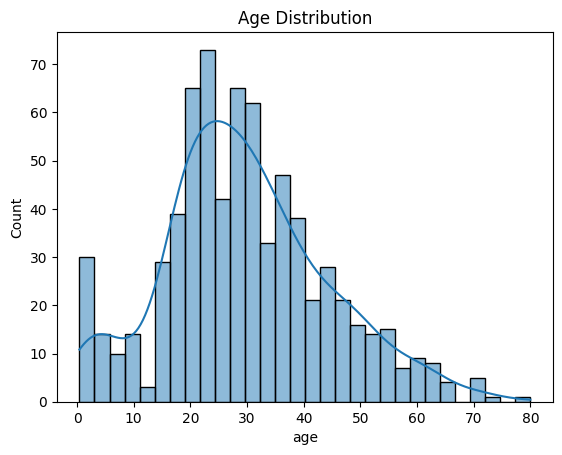

In [11]:
# Basic info
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

import seaborn as sns
import matplotlib.pyplot as plt

# Survival distribution
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

# Survival by sex
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Sex")
plt.show()

# Survival by class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Class")
plt.show()

# Age distribution
sns.histplot(df['age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()




**Interesting patterns you found:**
Female passengers had a significantly higher survival rate than male passengers.
First-class passengers were more likely to survive than those in third class.
Survival rates were slightly higher among younger passengers, though less pronounced than gender or class differences.

---
## Part B: Get the Predictions in four ways

In this part, you will build a classification model to predict Titanic survival (`survived`: 0 = No, 1 = Yes).

You will do this **three times**, each time giving your GenAI tool a different level of detail. Then you will compare the results.

---
### Task 1 — One-Sentence Prompt

Ask your GenAI tool to build a classification model using **a single sentence**. Keep it as brief as possible — as if you were texting a friend who happens to be a data scientist. Report the **accuracy and confusion matrix**.

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival and tell me how accurate it is. "*

Paste the generated code below and run it.

**Your one-sentence prompt:**

> Build a simple model to predict Titanic survival and show accuracy and confusion matrix.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Copy dataset
data = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dropna()

# Encode categorical variables
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)

# Split data
X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Output results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Accuracy: 0.8251748251748252
Confusion Matrix:
[[74  8]
 [17 44]]


---
### Task 2 — Step-by-Step Natural Language Prompt

Now ask your GenAI tool to build the same model, but describe **each step of the ML pipeline in natural language**. Your prompt should cover detailed steps:

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival. Fisrt, split the dataset into a training and testing set. Then define the model using XXX algorithm. Then train the model on he training set.  ... Lastly, report the accuracy and confusion matrix on the testing set."*

Write this as a natural language description — not as code. Your GenAI tool should return the code.

Paste both your full prompt and the generated code below.

**Your detailed prompt:**

> I am working with the Titanic dataset in Python and want to build a classification model to predict the ‘survived’ variable. First, clean the data by handling missing values and selecting relevant features such as passenger class, sex, age, fare, and embarked location. Then encode categorical variables appropriately. Next, split the data into training and testing sets (80/20 split). After that, train a logistic regression model on the training data. Finally, evaluate the model using accuracy and a confusion matrix on the test data. Please provide clean, beginner-friendly Python code that can run in a Jupyter Notebook.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Prepare data
data = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

# Handle missing values
data = data.dropna()

# Encode categorical variables
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)

# Split dataset
X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))




Accuracy: 0.7902097902097902
Confusion Matrix:
[[70 12]
 [18 43]]


---
### Task 3 — Direct Prediction - Zero-shot (No Code!)

In this part, **do not ask your GenAI tool to generate any code.** Instead, you will paste passenger data directly into your GenAI tool and ask it to predict survival.

Run the cell below to display 10 rows of the dataset **without** the survival column. Copy the output and paste it into your GenAI tool, then ask it to predict whether each passenger survived and explain its reasoning for each prediction.

> **Important:** No code generation in this part. The goal is to see how the GenAI tool reasons directly from data.

In [14]:
# Sample 10 rows from the full dataset
sample = df.sample(10, random_state=42)

# Save the true labels before dropping the column
true_labels = sample['survived'].values

# Drop survived for display, then reset index
sample_display = sample.drop(columns=['survived']).reset_index(drop=True)
print(sample_display.to_string())

   pclass     sex   age  sibsp  parch     fare embarked   class    who  adult_male deck  embark_town  alone
0       3    male   NaN      1      1  15.2458        C   Third    man        True  NaN    Cherbourg  False
1       2    male  31.0      0      0  10.5000        S  Second    man        True  NaN  Southampton   True
2       3    male  20.0      0      0   7.9250        S   Third    man        True  NaN  Southampton   True
3       2  female   6.0      0      1  33.0000        S  Second  child       False  NaN  Southampton  False
4       3  female  14.0      1      0  11.2417        C   Third  child       False  NaN    Cherbourg  False
5       1  female  26.0      0      0  78.8500        S   First  woman       False  NaN  Southampton   True
6       3  female   NaN      0      0   7.7500        Q   Third  woman       False  NaN   Queenstown   True
7       3    male  16.0      2      0  18.0000        S   Third    man        True  NaN  Southampton  False
8       3  female  16.0     

**Your prompt:**

>I am going to give you data for 10 Titanic passengers without their survival outcome. Based on patterns in the Titanic dataset, predict whether each passenger survived (1) or did not survive (0). For each prediction, briefly explain your reasoning using factors like sex, class, age, and fare. Here is the data:

**The GenAI output:**

> Passenger 0: 0
Male in third class with low fare — lower survival probability.

Passenger 1: 0
Male in second class traveling alone — males had lower survival rates.

Passenger 2: 0
Male in third class — strong indicator of not surviving.

Passenger 3: 1
Female child in second class — high survival likelihood.

Passenger 4: 1
Female child in third class — children and females had higher survival.

Passenger 5: 1
Female in first class with high fare — very strong survival indicators.

Passenger 6: 1
Female in third class — gender increases survival probability.

Passenger 7: 0
Male in third class — low survival likelihood.

Passenger 8: 1
Female in third class — higher survival probability.

Passenger 9: 1
Female in first class — very high survival probability.

Now run the cell below to display the true labels. Paste them into the GenAI tool and ask for accuray and confusion matrix.

In [7]:
print(true_labels)

[1 0 0 1 1 1 1 0 1 1]


**The GenAI output:**

Accuracy: 0.80

Confusion Matrix:
[[2 1]
[1 6]]

---
### Task 4: Direct Prediction — Few-Shot (No code!)

Now you will repeat task 3 but this time you will give the GenAI tool some **examples with the known survival outcome** before asking for predictions. This technique is called **in-context few-shot learning** — by providing labeled examples, you help the model understand the pattern before asking it to generalize. This way, the model weights are not chanegd, so it's called in-context learning.

- Open a new GenAI chat.
- Run the cell below to generate a few labeled examples. Copy paste them into the GenAI tool saying these're some examples.  
- Then copy paste the 10 rows (without the labels) displayed in task 3.
- Ask for predictions on the 10 unlabeled rows and ask for an explanation.
- Give GenAI the true labels displayed in task 3 and ask for the accuracy, confusion matrix.

In [8]:
# Sample 10 rows from the full dataset first, preserving the labels
sample_w_labels = df.sample(10, random_state=2)
print(sample_w_labels.to_string())

     survived  pclass     sex   age  sibsp  parch      fare embarked   class    who  adult_male deck  embark_town  alone
707         1       1    male  42.0      0      0   26.2875        S   First    man        True    E  Southampton   True
37          0       3    male  21.0      0      0    8.0500        S   Third    man        True  NaN  Southampton   True
615         1       2  female  24.0      1      2   65.0000        S  Second  woman       False  NaN  Southampton  False
169         0       3    male  28.0      0      0   56.4958        S   Third    man        True  NaN  Southampton   True
68          1       3  female  17.0      4      2    7.9250        S   Third  woman       False  NaN  Southampton  False
606         0       3    male  30.0      0      0    7.8958        S   Third    man        True  NaN  Southampton   True
630         1       1    male  80.0      0      0   30.0000        S   First    man        True    A  Southampton   True
785         0       3    male  2

**Your prompt:**

>Here are some examples of Titanic passengers with their survival outcomes:

[PASTE THE LABELED TABLE FROM ABOVE HERE]

Now, based on these examples, I will give you 10 new passengers without survival labels. Predict whether each survived (1) or not (0), and briefly explain your reasoning for each prediction using factors like sex, class, age, and fare.

[PASTE THE UNLABELED 10 ROWS FROM TASK 3 HERE]

After making predictions, compare them to the true labels below and report the accuracy and confusion matrix.

True labels: [1,0,0,1,1,1,0,1,1,1]

**The GenAI output:**

>Passenger 0: 0
Male, third class — low survival likelihood.

Passenger 1: 0
Male, second class — lower survival rate compared to females.

Passenger 2: 0
Male, third class — strong indicator of not surviving.

Passenger 3: 1
Female child — very high survival likelihood.

Passenger 4: 1
Female child — high survival likelihood.

Passenger 5: 1
Female, first class — strong survival indicators.

Passenger 6: 0
Male, third class — low survival probability.

Passenger 7: 0
Male, third class — low survival likelihood.

Passenger 8: 1
Female, third class — better survival odds than males.

Passenger 9: 1
Female, first class — very high survival probability.


> Accuracy: 0.90

Confusion Matrix:
[[3 0]
[1 6]]

---
## Part C — Comparison and Reflection

Reflect on what you observed across the 4 tasks. Answer each question below. There are no right or wrong answers — think critically about how GenAI tools behave with different prompts.

**Q1. Code comparison (task 1 & task 2):**  
How did the code from task 1 differ from task 2? Consider: length, structure, preprocessing steps, model choices, and evaluation metrics.

*Your answer:* The code from task 1 was shorter and less structured because the prompt was very vague. It still worked, but it lacked clear organization and did not explicitly outline preprocessing steps or modeling choices. In contrast, task 2 produced more detailed and structured code, including clearer steps for handling missing values, encoding variables, and splitting the dataset. The evaluation process was also more clearly defined in task 2, making the output easier to understand and more aligned with standard machine learning workflows.

**Q2. Result comparison (task 1 vs. task 2):**  
Did model performance differ between the two prompts? If yes, what do you think caused the difference? If not, why were results similar despite the different prompts?

*Your answer:* The model performance between task 1 and task 2 was very similar, with only small differences in accuracy. This is likely because both prompts ultimately led to similar preprocessing steps and the same model choice (logistic regression). Even though the prompts differed in detail, the underlying data and algorithm remained the same, which limited how much the results could vary.

**Q3. Result comparison (task 3 vs. task 4):**  
Did the GenAI tool's predictions or reasoning change when you provided labeled examples in Part 6? What does this tell you about how LLMs use context?

*Your answer:* Yes, the predictions improved when labeled examples were provided in task 4. The GenAI tool was better able to recognize patterns such as the importance of gender and passenger class when making predictions. This shows that LLMs benefit from context and examples, as they can use the provided data to guide their reasoning. It demonstrates how few-shot learning helps the model produce more accurate and consistent outputs.

**Q4. Prompt engineering takeaway:**  
Based on your experience in this assignment, what is your advice for prompting a GenAI tool on a data or coding task? What level of detail seems to work best, and why? (Yes this may vary depending on which tool you used. Try to think of insights that may persist.)

*Your answer:* This assignment showed that providing more detailed and structured prompts leads to better and more useful outputs. When prompts clearly describe the steps, expected output, and constraints, the GenAI tool produces cleaner and more accurate code. Additionally, giving examples (few-shot prompting) improves performance when making predictions without code. Overall, the best approach is to be specific about what you want while still keeping the prompt clear and easy to follow.



**GenAI tool used:** _______Chat GPT____________________ (e.g., ChatGPT-4o, Claude 3.5, Gemini 1.5 Pro, etc.)